## Importing Important Libaries

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Datasets Loading

In [11]:
movies=pd.read_csv("/content/movies.csv")

In [12]:
rating=pd.read_csv("/content/ratings.csv")

## Some Preprocessing

In [ ]:
movies.isnull().sum()

,0
movieId,0
title,0
genres,0


In [ ]:
rating.isnull().sum()

,0
userId,0
movieId,0
rating,0
timestamp,0


In [ ]:
rating.duplicated().sum()

np.int64(0)

In [ ]:
movies.duplicated().sum()

np.int64(0)

In [ ]:
movies.columns

Index(['movieId', 'title', 'genres'], dtype='object')

In [ ]:
rating.columns

Index(['userId', 'movieId', 'rating', 'timestamp'], dtype='object')

## Merging Datasets

In [13]:
df=rating.merge(movies,on="movieId")

In [14]:
df=df.sample(50000)

In [15]:
df.shape

(50000, 6)

In [16]:
df.isnull().sum()
df=df.dropna()

In [17]:
df.isnull().sum()

,0
userId,0
movieId,0
rating,0
timestamp,0
title,0
genres,0


In [18]:
df.shape

(50000, 6)

In [19]:
df=df.drop("timestamp",axis=1)

In [20]:
df.describe()

,userId,movieId,rating
count,50000.000000,50000.000000,50000.000000
mean,4987.335220,21146.064480,3.548290
std,2815.123078,38951.915506,1.052941
min,1.000000,1.000000,0.500000
25%,2539.000000,1193.000000,3.000000
50%,5040.000000,2868.000000,4.000000
75%,7403.000000,8596.000000,4.000000
max,9818.000000,207309.000000,5.000000


In [21]:
df['movieId'].sample(10)

,movieId
305324,1234
91294,2000
156771,596
1097900,3508
319221,4367
707904,95441
1095579,383
462075,2248
805745,2302
1020152,25


# movie with highest rating

In [22]:
print(df.sort_values(by="rating", ascending=False))

         userId  movieId  rating  \
110930      836     1449     5.0   
639608     4393     2081     5.0   
732412     4992     1198     5.0   
876326     5886    48516     5.0   
50341       408    54503     5.0   
...         ...      ...     ...   
444106     3055      876     0.5   
365234     2497   111759     0.5   
1231456    8319     2694     0.5   
1046400    7035     6485     0.5   
180773     1282     7345     0.5   

                                                     title  \
110930                          Waiting for Guffman (1996)   
639608                          Little Mermaid, The (1989)   
732412   Raiders of the Lost Ark (Indiana Jones and the...   
876326                                Departed, The (2006)   
50341                                      Superbad (2007)   
...                                                    ...   
444106      Supercop 2 (Project S) (Chao ji ji hua) (1993)   
365234                             Edge of Tomorrow (2014)   
1231456  

<Axes: >

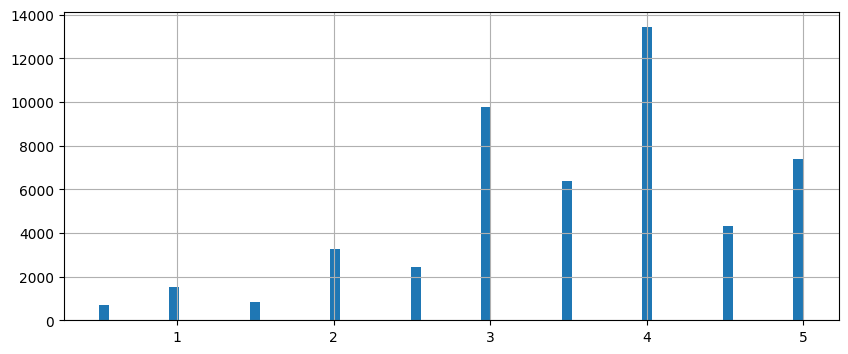

In [23]:
plt.figure(figsize = (10,4))
df['rating'].hist(bins = 70)

## Pivot tabel

In [47]:
user_movie_matrix=pd.pivot_table(df,index="userId",columns="movieId",values="rating")

In [48]:
user_movie_matrix

movieId,1,2,3,4,5,6,7,8,9,10,...,204528,204580,204690,204698,204838,205054,205072,205425,206499,207309
userId,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9814,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9815,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9816,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [49]:
user_movie_matrix = user_movie_matrix.fillna(0)

In [50]:
user_movie_matrix

movieId,1,2,3,4,5,6,7,8,9,10,...,204528,204580,204690,204698,204838,205054,205072,205425,206499,207309
userId,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9814,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9815,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9816,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [29]:
from sklearn.metrics.pairwise import cosine_similarity

In [51]:
user_similarity = cosine_similarity(user_movie_matrix)

print(user_similarity.shape)

(8308, 8308)


In [52]:
user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_movie_matrix.index,
    columns=user_movie_matrix.index
)

print(user_similarity_df.head(5))

userId  1         2         3     4     5     6         8     9         10    \
userId                                                                         
1        1.0  0.000000  0.000000   0.0   0.0   0.0  0.000000   0.0  0.000000   
2        0.0  1.000000  0.039936   0.0   0.0   0.0  0.000000   0.0  0.000000   
3        0.0  0.039936  1.000000   0.0   0.0   0.0  0.083424   0.0  0.195646   
4        0.0  0.000000  0.000000   1.0   0.0   0.0  0.000000   0.0  0.000000   
5        0.0  0.000000  0.000000   0.0   1.0   0.0  0.000000   0.0  0.000000   

userId  12    ...  9809  9810  9811  9812  9813  9814  9815  9816  9817  9818  
userId        ...                                                              
1        0.0  ...   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  
2        0.0  ...   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  
3        0.0  ...   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  
4        0.0  ...   0.0   0.0   0.0   0

In [53]:
similar_users = user_similarity_df[1].sort_values(ascending=False)

print(similar_users.head())

userId
1       1.000000
2222    0.348303
2509    0.231928
9318    0.178836
5980    0.024029
Name: 1, dtype: float64


In [54]:
movie_similarity = cosine_similarity(user_movie_matrix.T)

## Movie Base Similarity

In [55]:
movie_user_matrix=pd.pivot_table(df,index="movieId",columns="userId",values="rating")

In [56]:
movie_similarity_df = pd.DataFrame(
    movie_similarity,
    index=movie_user_matrix.index,
    columns=movie_user_matrix.index
)

print(movie_similarity_df.head(5))

movieId  1         2       3       4         5         6         7       \
movieId                                                                   
1           1.0  0.000000     0.0     0.0  0.000000  0.000000  0.022334   
2           0.0  1.000000     0.0     0.0  0.036086  0.065328  0.000000   
3           0.0  0.000000     1.0     0.0  0.000000  0.000000  0.025184   
4           0.0  0.000000     0.0     1.0  0.000000  0.000000  0.000000   
5           0.0  0.036086     0.0     0.0  1.000000  0.000000  0.039775   

movieId  8         9         10      ...  204528  204580  204690  204698  \
movieId                              ...                                   
1           0.0  0.000000  0.000000  ...     0.0     0.0     0.0     0.0   
2           0.0  0.080159  0.056397  ...     0.0     0.0     0.0     0.0   
3           0.0  0.000000  0.000000  ...     0.0     0.0     0.0     0.0   
4           0.0  0.000000  0.000000  ...     0.0     0.0     0.0     0.0   
5           0.0  0

## Movies-based recommendation function

In [41]:
def recommend_movies(movie_id, n=5):
    similar_scores = movie_similarity_df[movie_id].sort_values(ascending=False)
    top_movies = similar_scores.iloc[1:n+1]

    return movies[movies['movieId'].isin(top_movies.index)][['title']]

In [43]:
recommend_movies(2)

,title
2381,Tough Guys (1986)
5139,Smokey and the Bandit (1977)
7083,Dr. Jekyll and Mr. Hyde (1941)
27395,The Coven (2015)
48110,Twelve Angry Men (1954)


In [44]:
df.sample(5)

,userId,movieId,rating,title,genres
950,4,3114,3.0,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy
926448,6217,52722,2.0,Spider-Man 3 (2007),Action|Adventure|Sci-Fi|Thriller|IMAX
488138,3352,455,1.0,Free Willy (1993),Adventure|Children|Drama
804052,5415,1517,4.0,Austin Powers: International Man of Mystery (1...,Action|Adventure|Comedy
276954,1929,168,4.0,First Knight (1995),Action|Drama|Romance


## User-based recommendation function

In [45]:
def recommend_for_user(user_id, n=5):
    similar_users = user_similarity_df[user_id].sort_values(ascending=False)[1:10]

    similar_user_ids = similar_users.index

    recommendations = df[df['userId'].isin(similar_user_ids)]
    top_movies = recommendations.groupby('movieId')['rating'].mean().sort_values(ascending=False)

    return movies[movies['movieId'].isin(top_movies.head(n).index)][['title']]